# 12 — Wave 1: Prompt-Level Abstention (current headline positive)

**Status: current.** Reads `evaluate_wave1_experiments` outputs
(`math500_wave1_results.json`) for every model in `wave1_matrix` that has
finished. Qwen MATH-500 Best-of-8 is complete; the DeepSeek and DeepSeek-Llama
cells populate automatically once their stages run.

This is the **between-prompt regime**, and the complement to notebook 11. There
the question was *which of these 8 samples is right* — and geometry only tied
the free output baselines. Here the question is *should the model answer this
problem at all* — and geometry clearly wins.

**Why this notebook exists:** E1 is the strongest positive result in the
project and previously had no notebook. The retired `evaluate_selective_prediction`
stage measured roughly the same thing but reported point estimates only; E1
adds prompt-cluster bootstrap CIs and, critically, the **trace-length baseline**
that the truncation audit showed can fake a geometry result.

**The result: `rmd_tail_q20` reaches 0.852 accuracy at 50% coverage** against a
full-coverage base of 0.620, versus length 0.748, entropy 0.692, logprob 0.704.
Against entropy that is +0.168 AURC [+0.115, +0.216], p < 0.001. Against
**length** — the confound baseline, i.e. "is this just truncation detection?" —
it is still +0.069 AURC [+0.043, +0.096], p < 0.001. That length gap is what
makes this a geometry result rather than a length result.

Note what E1 does *not* claim: this is prompt-level difficulty/abstention, not
per-attempt correctness detection. Answering is done by majority vote; geometry
only decides *whether* to answer.

In [6]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

candidate_dirs = [Path.cwd(), Path.cwd() / "notebooks", *[p / "notebooks" for p in Path.cwd().parents]]
for candidate in candidate_dirs:
    if (candidate / "_viz_utils.py").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError("Could not locate notebooks/_viz_utils.py")

import _viz_utils as vu

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
})

ROOT = vu.results_root()

# Every model in wave1_matrix that has completed results. Qwen is the only one
# finished today; the loop picks up deepseek / deepseek_llama automatically once
# their evaluate_wave1_experiments stages land.
CANDIDATES = ["qwen", "deepseek", "deepseek_llama"]

results = {}
for model in CANDIDATES:
    path = ROOT / f"{model}_bestofn_full" / "math500" / "math500_wave1_results.json"
    if path.exists():
        results[model] = vu.load_json(path)

if not results:
    raise FileNotFoundError("No wave1 results found - run evaluate_wave1_experiments first")

for model, payload in results.items():
    s = payload["settings"]
    print(f"{model}: layers={s['layers']} deepest={s['deepest_layer']} "
          f"n_bootstrap={s['n_bootstrap']} n_prompts={payload['e1_prompt_abstention']['n_prompts']}")
    print(f"    censoring: {s['censoring']}")

qwen: layers=[7, 14, 21] deepest=21 n_bootstrap=1000 n_prompts=500
    censoring: unparsed and cap-hit traces excluded from correctness comparisons


## 1. Risk–coverage curves

**The task.** The model is allowed to say "I don't know". Rank all 500 problems
by a confidence scorer, answer the most-confident fraction `c` by majority vote
over its 8 samples, defer the rest, and measure accuracy **on the problems it
chose to answer**. Sweeping `c` from 1.0 down to 0 traces a risk–coverage curve.

**Why the curve shape is the result.** At full coverage every scorer is
identical by construction — same 500 problems, same majority-vote answers,
accuracy 0.620. The scorers can only differ in the *order* they defer. A good
scorer defers the problems the model was going to get wrong, so accuracy on the
remainder climbs steeply as coverage falls. A useless scorer defers at random
and the curve stays flat. **Curve height at low coverage is the whole signal.**

**Scorers.** Geometry (solid): `rmd_tail_q20` — RMD over the final 20% of
tokens; `rmd_high_entropy_q20` — RMD over the highest-entropy 20%. Free
baselines (dashed): `entropy`, `logprob`, and — critically — `length`.

**Watch the red `length` curve.** Trace length is the confound baseline. A trace
that hit the token cap is both long and almost certainly wrong, so "defer long
traces" is a genuinely strong heuristic here that involves no geometry at all
(AURC 0.759, well above entropy's 0.660). Any geometry claim has to clear
*length*, not just entropy. Beating entropy alone would be close to meaningless.

Aggregation is over problems, and all 8 samples of a problem move together —
the deferral decision is prompt-level, not trace-level.

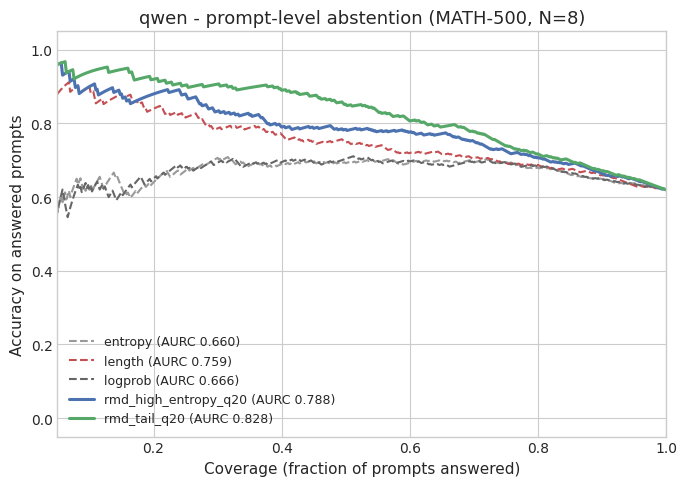

In [7]:
# Risk-coverage curves. The question is not "is accuracy high" but "does
# deferring the lowest-confidence prompts raise accuracy on what remains, and
# does geometry defer better than the free baselines?"
GEOMETRY = {"rmd", "rmd_high_entropy_q20", "rmd_tail_q20"}
COLORS = {
    "entropy": "#999999",
    "logprob": "#666666",
    "length": "#C44E52",          # the confound baseline, called out explicitly
    "rmd_high_entropy_q20": "#4C72B0",
    "rmd_tail_q20": "#55A868",
    "rmd": "#8172B2",
}

fig, axes = plt.subplots(1, len(results), figsize=(7 * len(results), 5), squeeze=False)
for ax, (model, payload) in zip(axes.ravel(), results.items()):
    e1 = payload["e1_prompt_abstention"]
    for method, block in e1["point"].items():
        curve = block["curve"]
        ax.plot(
            curve["coverages"], curve["accuracies"],
            label=f"{method} (AURC {block['aurc']:.3f})",
            color=COLORS.get(method, "#333333"),
            lw=2.2 if method in GEOMETRY else 1.5,
            ls="-" if method in GEOMETRY else "--",
        )
    ax.set_xlabel("Coverage (fraction of prompts answered)")
    ax.set_ylabel("Accuracy on answered prompts")
    ax.set_title(f"{model} - prompt-level abstention (MATH-500, N=8)")
    ax.legend(loc="lower left")
    ax.set_xlim(0.05, 1.0)
fig.tight_layout()
plt.show()

## 2. Point estimates

Two summaries of each curve. **AURC** is the area under the risk–coverage curve
— a single number for the whole deferral schedule, higher is better here since
the curve plots accuracy (note this is the opposite convention from
risk-plotting AURC, where lower wins). **Accuracy at fixed coverage** reads the
curve at 0.5 and 0.8; both levels were fixed in advance rather than chosen after
seeing the curves.

**The ordering, and the gap that matters:**

| Scorer | AURC | acc@50% |
|:---|---:|---:|
| `rmd_tail_q20` | **0.828** | **0.852** |
| `rmd_high_entropy_q20` | 0.788 | 0.784 |
| `length` | 0.759 | 0.748 |
| `logprob` | 0.666 | 0.704 |
| `entropy` | 0.660 | 0.692 |

Against a full-coverage base accuracy of 0.620, answering only the
most-confident half by `rmd_tail_q20` yields **0.852** — a 23-point improvement
from deferral alone. Entropy manages 0.692 at the same coverage.

Note that **`length` is the second-best scorer**, comfortably ahead of both
output-uncertainty baselines. That is exactly why section 3 exists: the
interesting comparison is not geometry vs entropy but geometry vs length.

Note also which region wins. Here `tail_q20` leads; in the within-prompt regime
(notebook 11) `high_entropy_q20` led and `tail_q20` was weak, occasionally
significantly negative. The two regimes prefer **different** regions, which is
one reason to treat them as genuinely different phenomena rather than one signal
viewed two ways.

In [8]:
# Point estimates at the two pre-registered coverage levels.
for model, payload in results.items():
    e1 = payload["e1_prompt_abstention"]
    print(f"=== {model} ===")
    print(f"{'method':>24} {'AURC':>8} {'acc@50%':>9} {'acc@80%':>9}")
    print("-" * 53)
    for method, block in sorted(e1["point"].items(), key=lambda kv: -kv[1]["aurc"]):
        acc = block["accuracy_at_coverage"]
        print(f"{method:>24} {block['aurc']:8.3f} {acc['0.5']:9.3f} {acc['0.8']:9.3f}")
    print()

=== qwen ===
                  method     AURC   acc@50%   acc@80%
-----------------------------------------------------
            rmd_tail_q20    0.828     0.852     0.718
    rmd_high_entropy_q20    0.788     0.784     0.708
                  length    0.759     0.748     0.688
                 logprob    0.666     0.704     0.685
                 entropy    0.660     0.692     0.680



## 3. Paired contrasts with prompt-cluster bootstrap CIs

**Paired and clustered, both deliberate.** Each of 1,000 bootstrap draws
resamples **problems** (not traces), keeping all 8 samples of a problem together
so the interval respects their correlation. Within a draw, both scorers are
evaluated on the *same* resampled problems, so the CI is on the **difference** —
far tighter and more honest than comparing two independently noisy point
estimates.

Hollow markers are contrasts with p ≥ 0.05.

**The contrast that carries the claim is `rmd_tail_q20 − length`:**

| Contrast | delta AURC [95% CI] | p |
|:---|:---|---:|
| `rmd_tail_q20 − entropy` | +0.168 [+0.115, +0.216] | <0.001 |
| `rmd_tail_q20 − logprob` | +0.162 [+0.111, +0.209] | <0.001 |
| **`rmd_tail_q20 − length`** | **+0.069 [+0.043, +0.096]** | **<0.001** |
| `rmd_high_entropy_q20 − entropy` | +0.129 [+0.077, +0.173] | <0.001 |
| `rmd_high_entropy_q20 − length` | +0.030 [+0.002, +0.058] | 0.040 |

At 50% coverage the length contrast is +0.104 [+0.064, +0.144], p < 0.001.

**Why this reads as a geometry result.** The entropy and logprob contrasts are
large but weakly informative — those baselines are poor at this task. The length
contrast is the one that rules out the alternative explanation: if geometry were
merely detecting truncated, rambling traces, it could not beat length by 0.069
AURC with an interval nowhere near zero. Something in the hidden-state geometry
knows about problem difficulty beyond how long the model rambled.

**What it does not establish.** `rmd_high_entropy_q20 − length` is +0.030 with a
CI that barely clears zero (p=0.040) — only the tail region beats length
convincingly. And this is one model on one dataset; see the summary for scope.

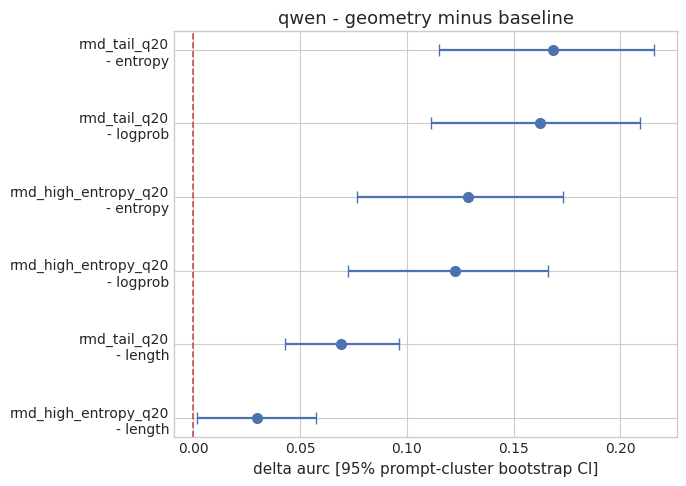

=== qwen ===
*                  rmd_high_entropy_q20 - length  +0.030 [+0.002, +0.058]  p=0.040
*                          rmd_tail_q20 - length  +0.069 [+0.043, +0.096]  p=0.000
*                 rmd_high_entropy_q20 - logprob  +0.122 [+0.072, +0.166]  p=0.000
*                 rmd_high_entropy_q20 - entropy  +0.129 [+0.077, +0.173]  p=0.000
*                         rmd_tail_q20 - logprob  +0.162 [+0.111, +0.209]  p=0.000
*                         rmd_tail_q20 - entropy  +0.168 [+0.115, +0.216]  p=0.000



In [9]:
# Paired prompt-cluster bootstrap deltas, geometry vs each free baseline.
# Only the contrasts that carry the claim; the report .md has all 12.
def delta_rows(payload, metric="aurc"):
    deltas = payload["e1_prompt_abstention"]["deltas"]
    rows = []
    for name, block in deltas.items():
        if not name.startswith("rmd_"):
            continue
        scorer, baseline = name.split("_minus_")
        d = block[metric]
        rows.append({
            "contrast": f"{scorer}\n- {baseline}",
            "point": d["point_estimate"],
            "lo": d["ci_low"],
            "hi": d["ci_high"],
            "p": d["p_two_sided"],
        })
    return sorted(rows, key=lambda r: r["point"])


METRIC = "aurc"
fig, axes = plt.subplots(1, len(results), figsize=(7 * len(results), 5), squeeze=False)
for ax, (model, payload) in zip(axes.ravel(), results.items()):
    rows = delta_rows(payload, METRIC)
    y = np.arange(len(rows))
    point = np.array([r["point"] for r in rows])
    lo = np.array([r["lo"] for r in rows])
    hi = np.array([r["hi"] for r in rows])
    sig = np.array([r["p"] < 0.05 for r in rows])
    ax.errorbar(
        point, y, xerr=[point - lo, hi - point], fmt="o",
        color="#4C72B0", ecolor="#4C72B0", capsize=4, lw=1.6, markersize=7,
    )
    # Non-significant contrasts hollowed out so the eye does not over-read them.
    ax.scatter(point[~sig], y[~sig], facecolors="white", edgecolors="#4C72B0", s=60, zorder=3)
    ax.axvline(0.0, color="#C44E52", lw=1.2, ls="--")
    ax.set_yticks(y)
    ax.set_yticklabels([r["contrast"] for r in rows])
    ax.set_xlabel(f"delta {METRIC} [95% prompt-cluster bootstrap CI]")
    ax.set_title(f"{model} - geometry minus baseline")
fig.tight_layout()
plt.show()

for model, payload in results.items():
    print(f"=== {model} ===")
    for r in delta_rows(payload, METRIC):
        mark = "*" if r["p"] < 0.05 else " "
        label = r["contrast"].replace("\n", " ")
        print(f"{mark} {label:>46}  {r['point']:+.3f} [{r['lo']:+.3f}, {r['hi']:+.3f}]  p={r['p']:.3f}")
    print()

## 4. Mechanism follow-ups — all negative

Four registered follow-ups, none of which worked. Keeping them visible here is
deliberate: they constrain what E1 can be read as showing.

- **E5 (event-locked RMD)** — *negative, and the control is why.* RMD does rise
  in the window before a high-entropy event at L21 (pre = +0.0147, CI
  [+0.0044, +0.0263], excludes zero) — but the matched **random-event control
  rises just as much** (+0.0135, CI [+0.0019, +0.0239]). The two are
  indistinguishable, so the apparent pre-event elevation is a property of the
  window, not of the event. Post-event slopes are null at every layer. Read
  against its control, E5 shows nothing.
- **E4 (entropy-trajectory autopsy)** — *negative.* Do shape features of the
  entropy trajectory (upper-tail mass, peak rate, peak position, post-peak
  decay) beat plain mean entropy within-prompt? No. Three of four are null and
  `mean_peak_position` is significantly *worse* (−0.162, p < 0.001). The entropy
  signal is a level, not a shape.
- **E6 (log-norm LVE)** — *negative at every layer.* A length-normalized
  log-volume estimate is significantly below plain logprob in all 15 cells
  (3 layers x 5 variants), and the token-order shuffle controls match the
  unshuffled versions — so whatever LVE measures, it is order-insensitive.
- **E7 (sibling eligibility)** — not a test but a power audit, and it explains
  the notebook-11 selection null structurally: of 500 prompts only 59 have at
  least two correct *and* two incorrect siblings after censoring. Paired
  within-prompt comparisons are underpowered by construction, no matter how good
  the scorer is.

E5 is the clearest illustration of why every localization claim in this project
is reported against a matched random control — see the `rmd_random_q20` control
in notebook 11, which is what makes the *high-entropy* localization result
credible where E5's event-locking is not.

In [10]:
# The mechanism follow-ups (E4-E7). E5 is a weak partial at L21; the rest are Recorded here so the E1
# positive is not read as "any geometry-flavoured feature works".
for model, payload in results.items():
    print(f"=== {model} ===")

    e5 = payload.get("e5_event_locked_rmd", {})

    def fmt(value, ci):
        return f"{value:+.4f} [{ci[0]:+.4f}, {ci[1]:+.4f}]"

    for layer, block in sorted(e5.get("layers", {}).items(), key=lambda kv: int(kv[0])):
        # random_rmd is the matched control: same window shape, events drawn at
        # random positions. RMD must beat it, not just beat zero.
        parts = []
        for series in ("rmd", "random_rmd"):
            b = block.get(series)
            if not b:
                continue
            parts.append(
                f"{series} pre={fmt(b['pre_event_mean'], b['pre_event_ci'])} "
                f"post-slope={fmt(b['post_event_slope'], b['post_event_slope_ci'])}"
            )
        print(f"E5 event-locked, L{layer}: " + " | ".join(parts))

    e4 = payload.get("e4_entropy_trajectory", {})
    print(f"E4 entropy-trajectory autopsy ({e4.get('n_mixed_prompts', '?')} mixed prompts)")
    print("  centered-AUC delta vs mean entropy:")
    for feature, block in e4.get("features", {}).items():
        c = block["prompt_centered_auc"]
        print(f"    {feature:>36} {c['point_estimate']:+.3f} "
              f"[{c['ci_low']:+.3f}, {c['ci_high']:+.3f}] p={c['p_two_sided']:.3f}")

    e6 = payload.get("e6_log_norm_lve", {})
    for layer, block in e6.get("layers", {}).items():
        print(f"E6 log-norm LVE, L{layer}:")
        for metric, stats in block.get("metrics", {}).items():
            c = stats["prompt_centered_auc"]
            print(f"    {metric:>36} {c['point_estimate']:+.3f} "
                  f"[{c['ci_low']:+.3f}, {c['ci_high']:+.3f}] p={c['p_two_sided']:.3f}")

    e7 = payload.get("e7_sibling_eligibility", {})
    if e7:
        print("E7 sibling eligibility (why paired within-prompt tests are underpowered):")
        for k, v in e7.items():
            print(f"    {k:>36} {v}")
    print()

=== qwen ===
E5 event-locked, L7: rmd pre=+0.0041 [-0.0086, +0.0166] post-slope=+0.0073 [-0.0104, +0.0238] | random_rmd pre=+0.0039 [-0.0081, +0.0156] post-slope=+0.0024 [-0.0174, +0.0230]
E5 event-locked, L14: rmd pre=+0.0046 [-0.0062, +0.0156] post-slope=+0.0001 [-0.0140, +0.0129] | random_rmd pre=+0.0044 [-0.0068, +0.0151] post-slope=+0.0009 [-0.0141, +0.0161]
E5 event-locked, L21: rmd pre=+0.0147 [+0.0044, +0.0263] post-slope=-0.0011 [-0.0163, +0.0131] | random_rmd pre=+0.0135 [+0.0019, +0.0239] post-slope=-0.0047 [-0.0229, +0.0110]
E4 entropy-trajectory autopsy (117 mixed prompts)
  centered-AUC delta vs mean entropy:
           upper_tail_mass_minus_entropy +0.001 [-0.003, +0.006] p=0.678
                 peak_rate_minus_entropy +0.003 [-0.014, +0.018] p=0.724
        mean_peak_position_minus_entropy -0.162 [-0.243, -0.077] p=0.000
           post_peak_decay_minus_entropy -0.042 [-0.096, +0.011] p=0.140
E6 log-norm LVE, L21:
                  lve_mean_minus_logprob -0.136 [-0.196

## Summary

**Positive.** Prompt-level abstention is where hidden-state geometry pays off.
`rmd_tail_q20` beats every free baseline on AURC and at 50% coverage with
prompt-cluster bootstrap CIs excluding zero — including the length baseline, so
it is not reducible to truncation detection.

**Scope.** One model (Qwen), one dataset (MATH-500), N=8, answering by majority
vote. The pre-specified cross-model confirmation on DeepSeek and DeepSeek-Llama
is the next dependent stage; until it lands, this is a Qwen result.

**Boundaries.** Geometry does not select *among* samples (notebook 11, and E7
above shows why that test is underpowered anyway), does not survive as a
trajectory-shape feature (E4, and notebook 08), and does not pay for itself as
an early abort signal (notebook 10). The claim is narrow on purpose: geometry
knows which *problems* the model is about to get wrong.